### LLM Architecture

In [3]:
#GPT configs to be used later
GPT_CONFIG_124M = {
    "vocab_size" : 50257, #GPT-2's vocab size (to be used by BPE tokenizer)
    "context_length": 1024, #max number of tokens, # of position vectors 
    "emb_dim": 768, #embedding dimension 
    "num_heads": 12, #number of attention heads, like different attention mechanisms analyzed 
    "num_layers": 12, #transformer blocks(will learn)
    "drop_rate": 0.1, #drop 10% randomly during training to prevent overfitting
    "qkv_bias": False, #whether to include bias(will learn more too)
}

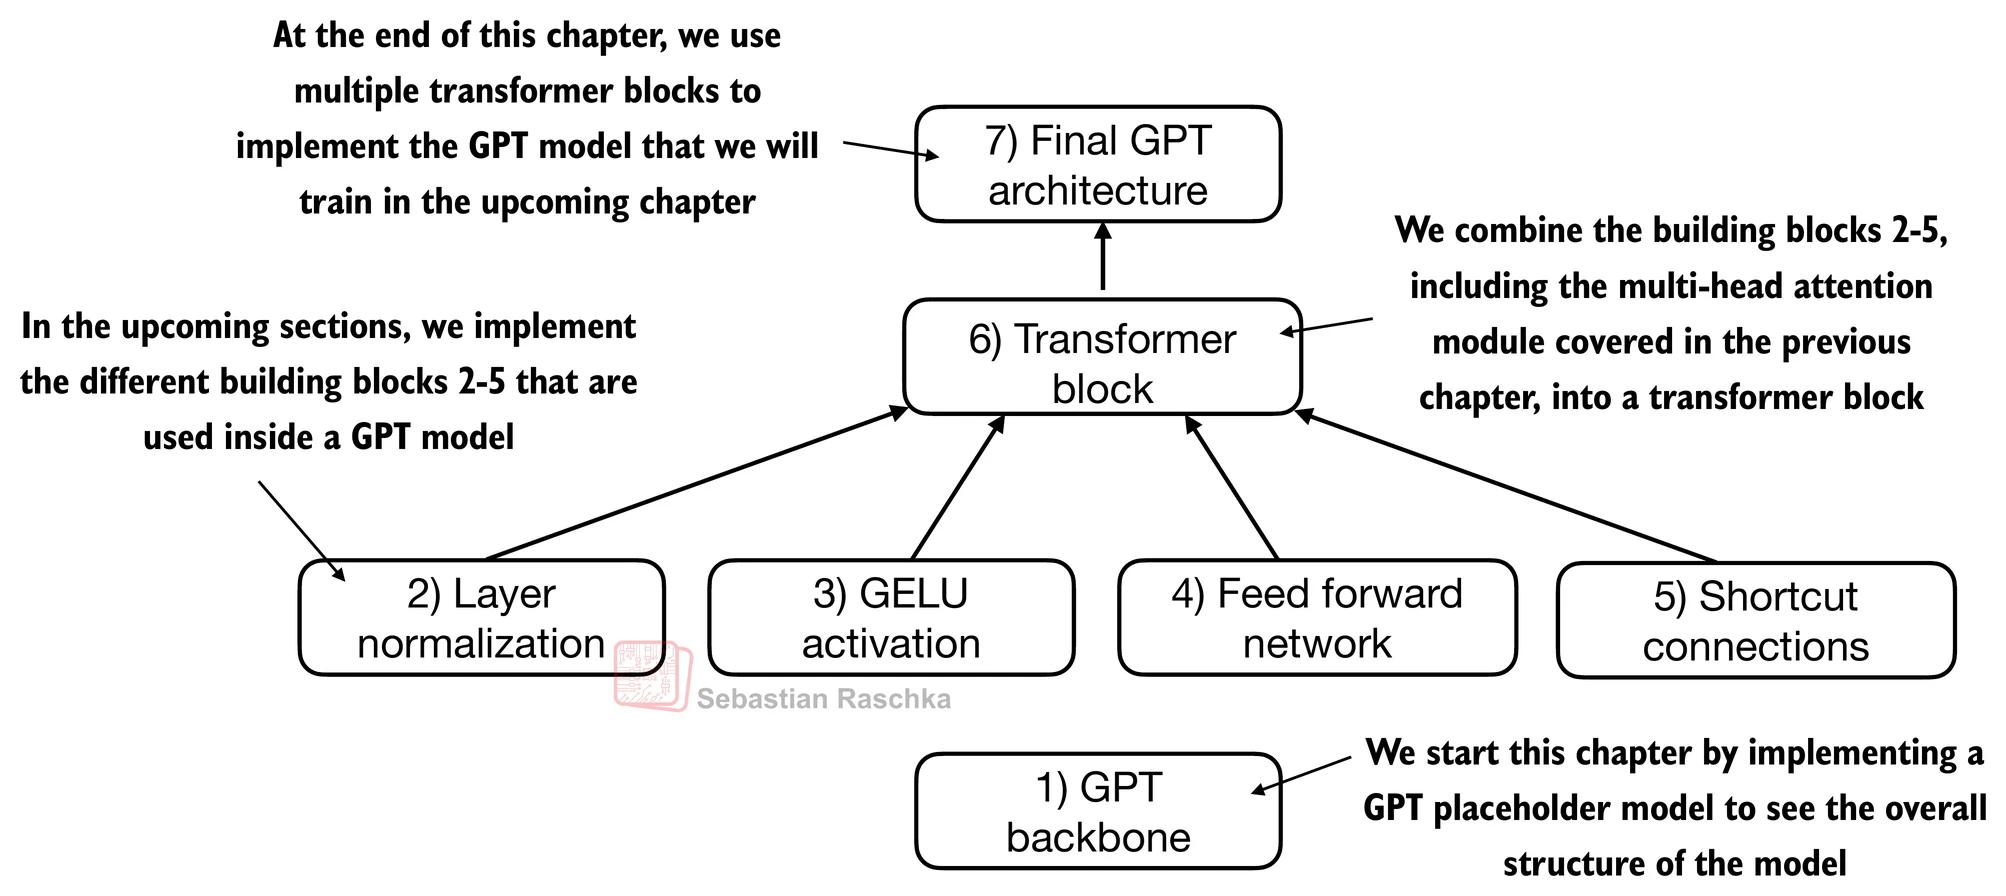


### **Prepare Data** 
- tokenize (tiktoken)
- turn to tensor (torch.tensor)


In [5]:
import tiktoken 
import torch
import torch.nn as nn

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Ever day holds a"

#tokenize text then convert to tensor and stack them to create input data
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[ 6109,  3626,  6100,   345],
        [23921,  1110,  6622,   257]])


In [4]:
torch.manual_seed(123)
from GPT_Model_architecture_class import DummyGPTmodel

model = DummyGPTmodel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-0.0678,  0.5159,  0.1443,  ..., -0.2633,  0.0214,  0.8341],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


[2,4,50257]

2-> batch size, # of rows/samples (txt1, txt2)
4 -> length per sample (4 words)
50257 -> number of unique words/subwords that GPT2 tokenizer has 

### **Normalizing activations with layer normalization**
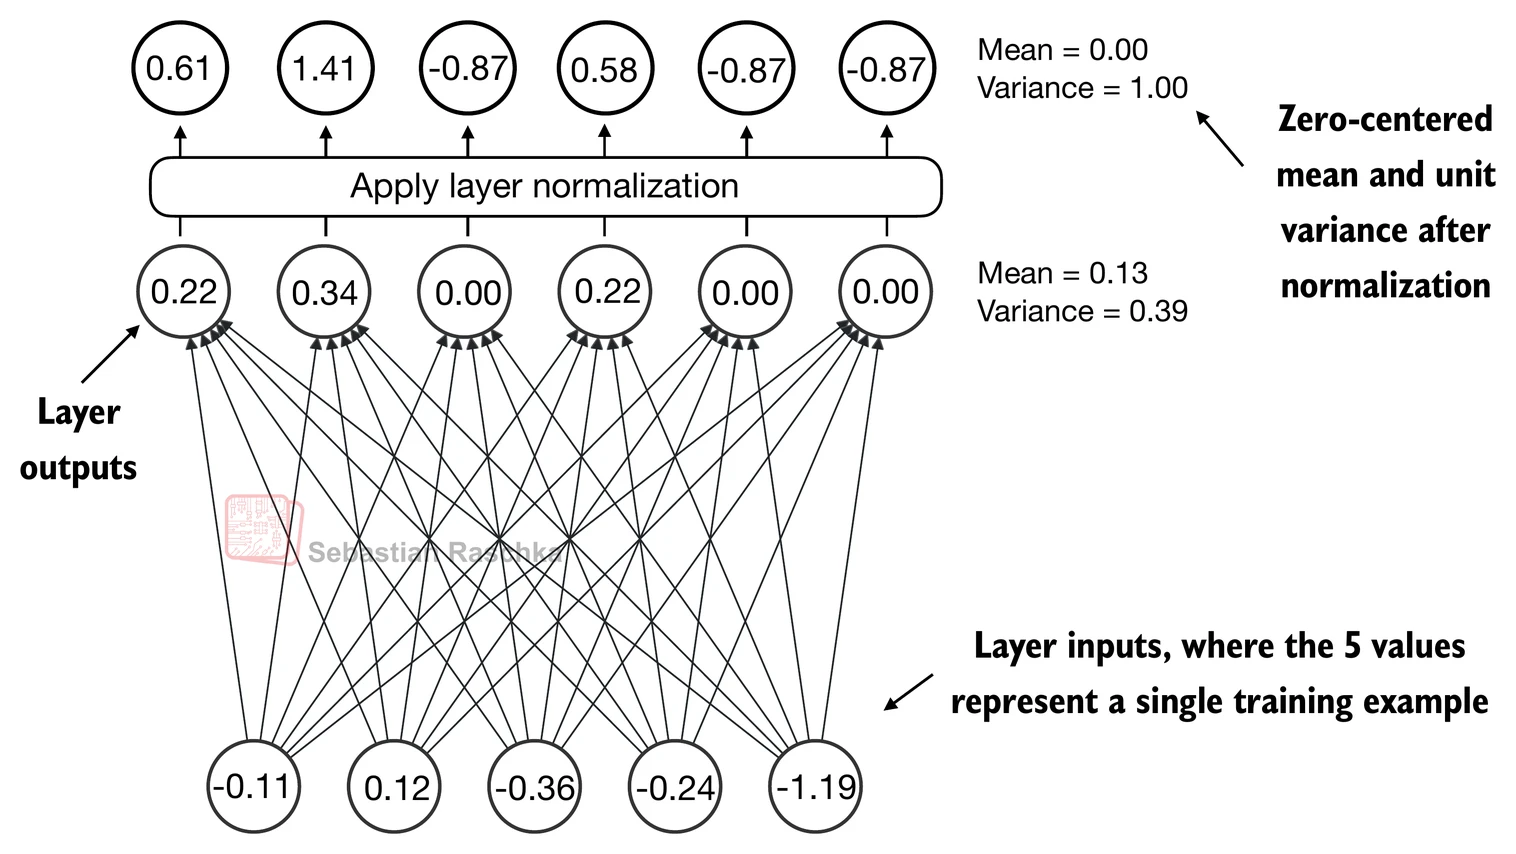

In [7]:
torch.manual_seed(123)

batch_example = torch.randn(2,5)
print(batch_example) #2 samples, 5 features each


layer = nn.Sequential( #sequential container to stack layers together
    nn.Linear(5,6),  #5 input features, 6 output features #linear transformation of the input data
    nn.ReLU() #filter, activation function only allow positive values through
)
out = layer(batch_example)
print(out) #output of the sequential layer, 2 samples, 6 features each

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
#look at the current mean and variance of the output

mean = out.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out.var(dim=-1, keepdim=True) #variance across features for each sample
print("Mean before normalization:", mean)
print("Variance before normalization:", var)


Mean before normalization: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance before normalization: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


'\nwhy dim = -1\nWhen data becomes multi-dimensional : (batch_size, num_tokens, emb_size)\nwe want to calculate mean and variance across the embedding dimension (features) for each token in each sample.\ndim=-1 means we are calculating mean and variance across the last dimension of the tensor, which is the embedding dimension in this case.\n'

why dim = -1

When data becomes multi-dimensional : (batch_size, num_tokens, emb_size)
we want to calculate mean and variance across the embedding dimension (features) for each token in each sample.
dim=-1 means we are calculating mean and variance across the last dimension of the tensor, which is the embedding dimension in this case.
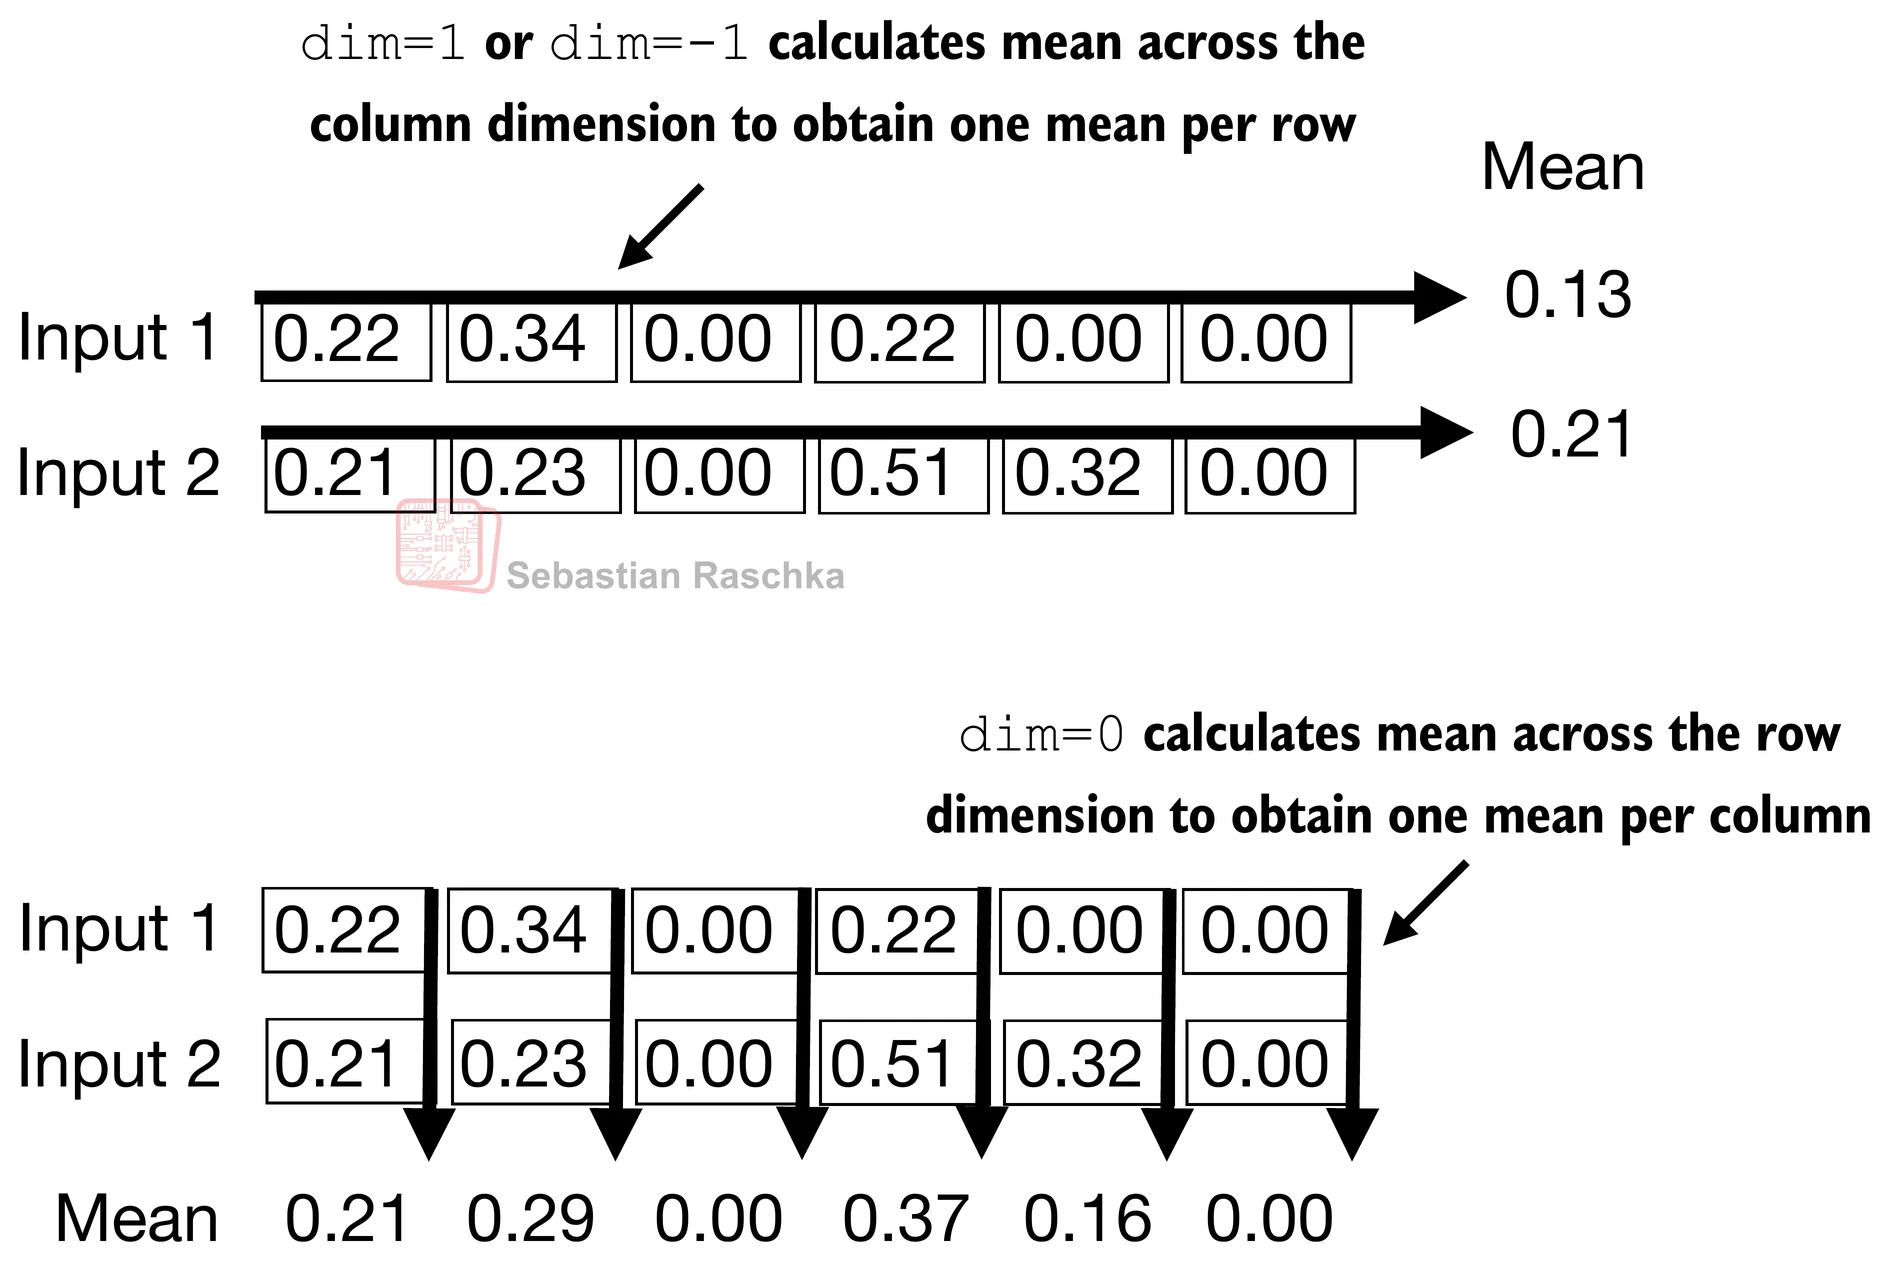

In [ ]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out_norm.var(dim=-1, keepdim=True) #variance across features for each sample
print("Normalized output:", out_norm)
print("Mean after normalization:", mean)
print("Variance after normalization:", var)

Normalized output: tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean after normalization: tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance after normalization: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)
